* Alessio Arcara
* alessio.arcara@studio.unibo.it

In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
from kornia.losses import FocalLoss

# Moduli progetto
from data.multi_epochs_dataloader import MultiEpochsDataLoader
from data.streethazards import (
    STREET_HAZARDS_CLASSES,
    StreetHazards,
    get_classes_as_dict,
)
from data.transforms import Denormalize, get_data_transforms
from models.model import build_model
from training.losses import (
    ObjectosphereLoss,
    PrototypicalGlobalLocalTripletLoss,
)
from training.metrics import AUPR, MeanIoU
from training.trainer import Trainer
from utils.misc import fix_random, generate_run_name, get_device, load_config
from utils.visualize import visualize_added_outlier, visualize_augmentations

# Configurazioni di ambiente
%load_ext autoreload
%autoreload 2

small survey about anomaly segmentation



Premessa: come il mio precedente notebook, link al notebook, sono interessato ad avere delle reti efficienti che mi permettano di poter trainare liberamente e fare diverse prove anche su un dispositivo mac con `mps`.

Guardando i diversi paper che ottenevano alti score nel benchmark SegmentMeIfYouCan, i migliori come mIoU utilizzano Mask classification e di conseguenza Mask2Former con l'aggiunta di un modulo o di tecniche per aggiungere anche il rilevamento di anomalie. Tra tutti ho preferito implementare il paper `Open Semantic Segmentation with Class Similarity` che ottiene un mIoU competitivo, rimanendo al contempo veloce a differenza degli approcci con Mask2Former più lenti di natura, e con un rilevamento di anomalie decisamente migliore. Successivamente, data la recente uscita del paper `Open Panoptic Segmentation`, sempre degli stessi autori, che oltre ad aggiungere la Panoptic Segmentation, risolve alcuni problemi del precedente approccio.

TODO

* Insert anomalies in validation set DONE
* mAP on anomalies
* open mIoU


fa fatica con i solar flare, potrai aggiungere una data augmentation nel training set e poi valutarla nell'ablation

In [2]:
config = load_config("./config.yaml")
fix_random(config["seed"])
device = get_device()

🚀 CUDA device is available!


In [3]:
TRAIN_ROOT = Path.home() / config["paths"]["train_path"]

data_transforms = get_data_transforms(
    img_height=config["training"]["img_height"],
    img_width=config["training"]["img_width"],
)
denorm = Denormalize()

train_data = StreetHazards(
    root_dir=TRAIN_ROOT, subset="training", transforms=data_transforms["train"]
)

val_data = StreetHazards(
    root_dir=TRAIN_ROOT, subset="validation", transforms=data_transforms["val"]
)

num_classes = len(STREET_HAZARDS_CLASSES)
class_dict = get_classes_as_dict()

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of classes: {num_classes}")

Number of training samples: 5125
Number of validation samples: 1031
Number of classes: 14


qui devo far vedere le augmentation

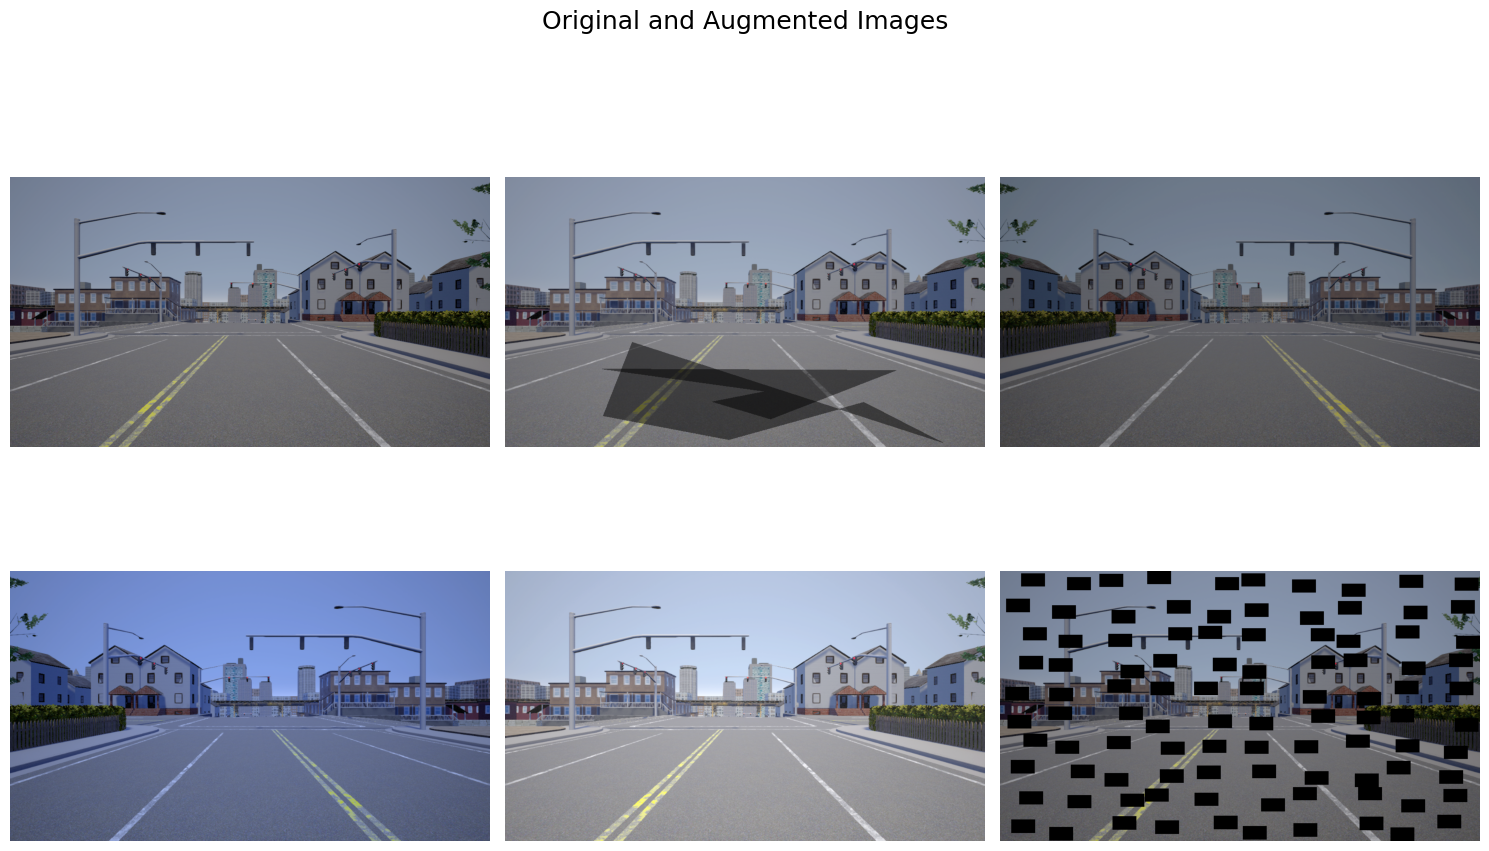

In [4]:
visualize_augmentations(train_data, data_transforms, denorm, num_samples=6)

In [5]:
NUM_WORKERS = os.cpu_count() - 1
cv2.setNumThreads(0)

train_loader = MultiEpochsDataLoader(
    train_data,
    batch_size=config["training"]["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=3,
)

val_loader = MultiEpochsDataLoader(
    val_data,
    batch_size=config["training"]["batch_size"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True,
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 854
Number of validation batches: 171


In [6]:
#class_weights = train_data.get_class_weights().to(device)
#class_weights = class_weights[:-1]
num_classes = num_classes - 1
print(num_classes)

13


COMMENTI:

* la wce converge meglio rispetto alla focal loss, ma risulta meno stabile e ogni tanto sul validation diverge decisamente
* best score right now on validation it's 0.55 mIoU,
* attualmente il mio modello fa fatica sulle parti lontane dell'immagine dove il modello non riesce a capire esattamente cosa c'è nell'immagine e sugli oggetti molto piccoli
* il modello non è preciso ai bordi, come affrontare il problema?
* aspp fa qualcosa?



In [7]:
do_train = False 

model, model_info = build_model(config, num_classes)

criterions = [
    (
        1.0,
        PrototypicalGlobalLocalTripletLoss(
            num_classes=num_classes,
            margin_global=config["losses"]["prototypical_triplet"]["global"],
            margin_local=config["losses"]["prototypical_triplet"]["local"],
            magnitude=config["losses"]["prototypical_triplet"]["anchors_magnitude"],
        ),
    ),
    (
        1.0,
        FocalLoss(
            alpha=config["losses"]["focal"]["alpha"],
            gamma=config["losses"]["focal"]["gamma"],
            reduction="mean",
        ),
    ),
]

trainer = Trainer(
    config,
    model,
    device,
    train_loader,
    criterions,
    denorm,
    val_loader,
    class_dict,
    [MeanIoU(num_classes)],
    True,
)

if do_train:
    run_name = generate_run_name(config, model_info, criterions)
    trainer.train(run_name)
else:
    model.load_state_dict(
        torch.load(
            "saved/models/ENC_efficientnet_b2_DEC_2FAM64_ASPP12-24-36_IMG1024x576_LOSS_PrototypicalGlobalLocalTripletLoss,FocalLoss_20250424_055239_epoch50_miou0.7133.pt",
            weights_only=True,
        )
    )

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/efficientnet_b2.ra_in1k)
INFO:timm.models._hub:[timm/efficientnet_b2.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


$$
\mathcal{L}(x, y) = \Biggl \lbrace { \max \lbrace 0, \xi - \lVert F(x) \rVert \rbrace^2 \quad \text{if } y \geq 0 \atop \lVert F(x) \rVert_2^2 \hspace{3.7cm} \text{ otherwise } }
$$

In [8]:
train_data_w_anomalies = StreetHazards(
    root_dir=TRAIN_ROOT,
    subset="training",
    transforms=data_transforms["val"],
    add_anomalies=True,
)

val_data_w_anomalies = StreetHazards(
    root_dir=TRAIN_ROOT,
    subset="validation",
    transforms=data_transforms["val"],
    add_anomalies=True,
)

train_loader_w_anomalies = MultiEpochsDataLoader(
    train_data_w_anomalies,
    batch_size=config["training"]["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

val_loader_w_anomalies = MultiEpochsDataLoader(
    val_data_w_anomalies,
    batch_size=config["training"]["batch_size"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True,
)

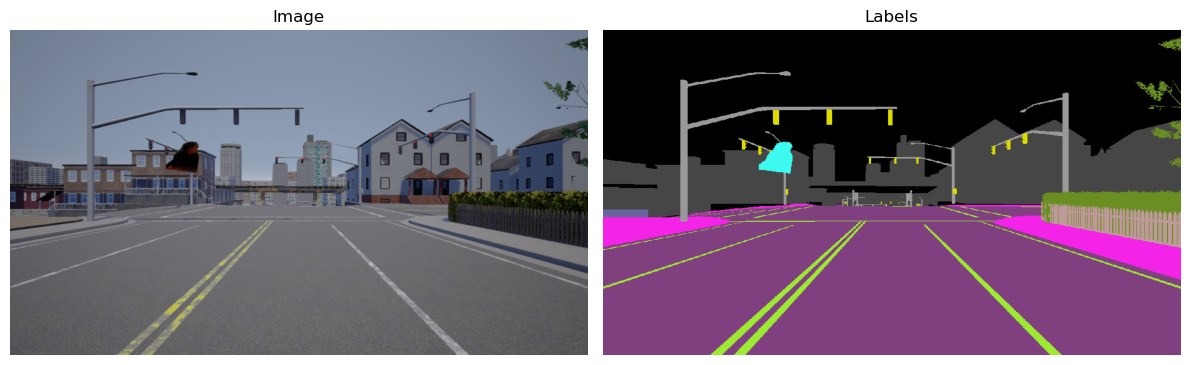

In [9]:
visualize_added_outlier(train_data_w_anomalies[0], denorm)

In [10]:
do_train = False

criterions = [
    (
        0.45,
        PrototypicalGlobalLocalTripletLoss(
            num_classes=num_classes,
            margin_global=config["losses"]["prototypical_triplet"]["global"],
            margin_local=config["losses"]["prototypical_triplet"]["local"],
            magnitude=config["losses"]["prototypical_triplet"]["anchors_magnitude"],
        ),
    ),
    (
        0.45,
        FocalLoss(
            alpha=config["losses"]["focal"]["alpha"],
            gamma=config["losses"]["focal"]["gamma"],
            reduction="mean",
            ignore_index=13,
        ),
    ),
    (0.10, ObjectosphereLoss(xi=5.0, unknown_label=13)),
]

trainer = Trainer(
    config,
    model,
    device,
    train_loader_w_anomalies,
    criterions,
    denorm,
    val_loader_w_anomalies,
    class_dict,
    [MeanIoU(num_classes), AUPR(unknown_label=13)],
    True,
)

if do_train:
    run_name = generate_run_name(config, model_info, criterions)
    trainer.train("OOD_" + run_name)
else:
    model.load_state_dict(
        torch.load(
            "saved/models/OOD_ENC_efficientnet_b2_DEC_2FAM64_ASPP12-24-36_IMG576x1024_LOSS_PrototypicalGlobalLocalTripletLoss,FocalLoss,ObjectosphereLoss_20250425_175255_epoch10_miou0.6953.pt",
            weights_only=True,
        )
    )

t classification approach takes advantage of the
label space induced by the LPTL, in which the KKC sam-
ples are projected closer to their corresponding prototypical
anchors. At the same time, the UUC samples are projected
toward the open space and, therefore, further away from the
prototypical anchors.

In [11]:
TEST_ROOT = Path.home() / config["paths"]["test_path"]

test_data = StreetHazards(TEST_ROOT, "test", transforms=data_transforms["val"])

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=2,
    shuffle=False,
    # num_workers=NUM_WORKERS,
    # pin_memory=True,
    # persistent_workers=True,
    # prefetch_factor=2
)

In [12]:
anchors = (
    torch.eye(num_classes, device="cuda")
    * config["losses"]["prototypical_triplet"]["anchors_magnitude"]
)

@torch.no_grad()
def anomaly_map(
    logits: torch.Tensor, anchors: torch.Tensor, threshold: float
) -> torch.Tensor:
    B, C, H, W = logits.shape
    device = logits.device
    anchors = anchors.to(device=device, dtype=logits.dtype)  # [K, C]

    embeds = logits.permute(0, 2, 3, 1).reshape(-1, C)  # [(B·H·W), C]

    # GPU–accelerated pair-wise L2 distances: [(B·H·W), K]
    dists = torch.cdist(embeds, anchors, p=2)

    min_dists, _ = dists.min(dim=1)  # [(B·H·W)]
    # anomaly_mask = (min_dists > threshold).reshape(B, H, W)

    return min_dists.reshape(B, H,W)

In [ ]:
from tqdm.notebook import tqdm

metrics = [MeanIoU(num_classes), AUPR(13)]
for imgs, masks in tqdm(test_loader):
    imgs = imgs.to(device)
    masks = masks.to(device)

    logits = model(imgs)
    pred = torch.argmax(logits, dim=1)

    anomaly_prob = anomaly_map(logits, anchors, None)
    for metric in metrics:
        metric.update(anomaly_prob, pred, masks)

for metric in metrics:
    print(metric.compute())

  0%|          | 0/750 [00:00<?, ?it/s]

tensor(0.5858, device='cuda:0')
tensor(0.2024, device='cuda:0')


In [27]:
import ipywidgets as widgets

from utils.visualize import COLORS, color

anchors = (
    torch.eye(num_classes, device="cuda")
    * config["losses"]["prototypical_triplet"]["anchors_magnitude"]
)

print(anchors)


@torch.no_grad()
def anomaly_map(
    logits: torch.Tensor, anchors: torch.Tensor, threshold: float
) -> torch.Tensor:
    B, C, H, W = logits.shape
    device = logits.device
    anchors = anchors.to(device=device, dtype=logits.dtype)  # [K, C]

    embeds = logits.permute(0, 2, 3, 1).reshape(-1, C)  # [(B·H·W), C]

    # GPU–accelerated pair-wise L2 distances: [(B·H·W), K]
    dists = torch.cdist(embeds, anchors, p=2)

    min_dists, _ = dists.min(dim=1)  # [(B·H·W)]
    anomaly_mask = (min_dists > threshold).reshape(B, H, W)
    return anomaly_mask


def visualize_predictions(model, dataset, device, threshold=0.5):
    model.eval()

    @torch.no_grad()
    def show_prediction(idx, threshold_value):
        """Funzione interna per visualizzare una singola predizione"""
        img, mask = dataset[idx]

        img = img.unsqueeze(0).to(device)

        with torch.inference_mode():
            logits = model(img)
            pred = torch.argmax(logits, dim=1)
            anomaly = anomaly_map(logits, anchors, threshold_value)

        plt.figure(figsize=(15, 10))

        plt.subplot(231)
        plt.imshow(denorm(img))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(232)
        plt.imshow(color(mask.squeeze(), COLORS))
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(233)
        plt.imshow(color(pred.cpu().squeeze(), COLORS))
        plt.title("Predicted")
        plt.axis("off")

        plt.subplot(234)
        plt.imshow(anomaly.cpu().squeeze(), cmap="hot")
        plt.title("Anomaly Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    idx_slider = widgets.IntSlider(
        value=0, min=0, max=len(dataset) - 1, step=1, description="Indice:"
    )

    threshold_slider = widgets.FloatSlider(
        value=threshold, min=0.0, max=50.0, step=0.1, description="Threshold:"
    )

    widgets.interact(show_prediction, idx=idx_slider, threshold_value=threshold_slider)

tensor([[10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.]],
       device='cuda:0')


In [28]:
anchors.shape

torch.Size([13, 13])

In [29]:
visualize_predictions(model, test_data, "cuda")

interactive(children=(IntSlider(value=0, description='Indice:', max=1499), FloatSlider(value=0.5, description=…

## steps per finire il progetto

- secondo validation set injectato con "anomalie"
- calcolo mean average precision

In [30]:
!pip install pytorch-ood 

768.12s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
